## Import Liberaries

In [3]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# import shap
import os
import json
import joblib
import shutil
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.inspection import permutation_importance
# from captum.attr import IntegratedGradients

## Pre-Processing

### Load data

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# train = pd.read_csv('train.csv')
# test = pd.read_csv('test.csv')
train= pd.read_csv('/content/drive/MyDrive/Irrigarion/train.csv')
test= pd.read_csv('/content/drive/MyDrive/Irrigarion/test.csv')

x_train = train.drop(['id', 'Irrigation_Need'], axis=1)
y_train = train['Irrigation_Need']

x_test = test.drop('id', axis=1)
y_test= pd.read_csv('/content/drive/MyDrive/Irrigarion/sample_submission.csv').drop(['id'], axis= 1)

print(f"Training data: {x_train.shape[0]} samples, {x_train.shape[1]} features")
print(f"Test data: {x_test.shape[0]} samples, {x_test.shape[1]} features")

Training data: 630000 samples, 19 features
Test data: 270000 samples, 19 features


In [6]:
x_train.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East
1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South
2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North
3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South
4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South


In [7]:
x_train.describe()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


In [8]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Soil_Type                630000 non-null  object 
 1   Soil_pH                  630000 non-null  float64
 2   Soil_Moisture            630000 non-null  float64
 3   Organic_Carbon           630000 non-null  float64
 4   Electrical_Conductivity  630000 non-null  float64
 5   Temperature_C            630000 non-null  float64
 6   Humidity                 630000 non-null  float64
 7   Rainfall_mm              630000 non-null  float64
 8   Sunlight_Hours           630000 non-null  float64
 9   Wind_Speed_kmh           630000 non-null  float64
 10  Crop_Type                630000 non-null  object 
 11  Crop_Growth_Stage        630000 non-null  object 
 12  Season                   630000 non-null  object 
 13  Irrigation_Type          630000 non-null  object 
 14  Wate

In [9]:
x_train.isnull().sum()

,0
Soil_Type,0
Soil_pH,0
Soil_Moisture,0
Organic_Carbon,0
Electrical_Conductivity,0
Temperature_C,0
Humidity,0
Rainfall_mm,0
Sunlight_Hours,0
Wind_Speed_kmh,0


In [10]:
x_test.isnull().sum()

,0
Soil_Type,0
Soil_pH,0
Soil_Moisture,0
Organic_Carbon,0
Electrical_Conductivity,0
Temperature_C,0
Humidity,0
Rainfall_mm,0
Sunlight_Hours,0
Wind_Speed_kmh,0


In [11]:
print(x_train.duplicated().sum())
print(x_test.duplicated().sum())

0
0


In [12]:
x_train.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East
1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South
2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North
3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South
4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South


### Encoding

In [14]:
cat_v= ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type',
        'Water_Source', 'Mulching_Used', 'Region']

num_v= (x_train.drop(columns=cat_v).columns).tolist()

for i in cat_v:
               print(f"{i}: {x_train[i].unique()}")

Soil_Type: ['Loamy' 'Clay' 'Sandy' 'Silt']
Crop_Type: ['Sugarcane' 'Wheat' 'Rice' 'Potato' 'Cotton' 'Maize']
Crop_Growth_Stage: ['Sowing' 'Vegetative' 'Flowering' 'Harvest']
Season: ['Zaid' 'Kharif' 'Rabi']
Irrigation_Type: ['Drip' 'Rainfed' 'Sprinkler' 'Canal']
Water_Source: ['Rainwater' 'River' 'Reservoir' 'Groundwater']
Mulching_Used: ['No' 'Yes']
Region: ['East' 'South' 'North' 'West' 'Central']


In [15]:
def safe_one_hot_encode(x_train, x_test, columns):

    for column_name in columns:

        if column_name in x_train.columns:

            train_dummies = pd.get_dummies(x_train[column_name], prefix=column_name)
            test_dummies = pd.get_dummies(x_test[column_name], prefix=column_name)


            x_train = x_train.drop(column_name, axis=1)
            x_test = x_test.drop(column_name, axis=1)

            x_train = pd.concat([x_train, train_dummies], axis=1)
            x_test = pd.concat([x_test, test_dummies], axis=1)

    x_train, x_test = x_train.align(x_test, join='left', axis=1, fill_value=0)

    return x_train, x_test

x_train_encoded, x_test_encoded = safe_one_hot_encode(x_train, x_test, cat_v)

x_train_encoded

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,...,Water_Source_Rainwater,Water_Source_Reservoir,Water_Source_River,Mulching_Used_No,Mulching_Used_Yes,Region_Central,Region_East,Region_North,Region_South,Region_West
0,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,0.82,...,True,False,False,True,False,False,True,False,False,False
1,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,5.27,...,False,False,True,False,True,False,False,False,True,False
2,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,8.24,...,False,True,False,False,True,False,False,True,False,False
3,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,8.32,...,False,False,True,False,True,False,False,False,True,False
4,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,7.37,...,False,False,True,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,6.54,13.45,1.15,1.86,26.65,26.86,1041.33,10.62,18.85,4.35,...,False,False,True,True,False,False,False,False,True,False
629996,7.03,54.49,0.96,2.35,36.99,88.00,1419.57,9.93,17.99,12.97,...,False,False,False,False,True,True,False,False,False,False
629997,6.52,11.98,0.93,0.38,37.82,70.98,88.45,8.19,17.25,13.58,...,False,True,False,False,True,False,False,False,True,False
629998,5.93,42.86,0.33,3.39,34.99,94.58,2433.92,9.88,5.00,0.79,...,False,False,False,False,True,False,True,False,False,False


In [16]:
x_test_encoded

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,...,Water_Source_Rainwater,Water_Source_Reservoir,Water_Source_River,Mulching_Used_No,Mulching_Used_Yes,Region_Central,Region_East,Region_North,Region_South,Region_West
0,6.36,26.19,0.59,2.81,17.83,30.24,1533.38,5.40,3.00,13.59,...,False,False,True,False,True,False,False,False,False,True
1,5.87,9.88,1.18,3.26,21.18,78.07,576.05,7.22,15.88,6.12,...,False,True,False,False,True,False,False,False,True,False
2,6.22,26.55,0.96,0.85,26.87,60.35,545.30,9.43,2.63,3.11,...,False,True,False,False,True,False,True,False,False,False
3,7.68,53.58,0.83,0.55,41.74,36.05,1211.03,6.69,1.86,2.27,...,False,False,False,True,False,False,False,True,False,False
4,5.23,59.02,0.54,2.11,41.08,52.47,1321.91,4.11,5.71,12.39,...,False,False,False,False,True,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
269995,5.63,51.90,0.68,2.58,33.27,72.09,2326.61,7.09,10.02,2.93,...,False,False,True,False,True,False,True,False,False,False
269996,7.84,45.16,0.85,1.04,27.55,45.16,2322.37,5.15,5.62,11.23,...,False,False,False,False,True,False,False,False,False,True
269997,7.83,11.02,1.56,1.90,23.39,64.87,996.72,10.44,9.98,2.88,...,False,False,False,False,True,False,True,False,False,False
269998,7.12,10.18,1.32,2.65,41.09,58.04,1130.71,5.11,1.46,5.71,...,False,False,True,False,True,False,True,False,False,False


### Remove outliers

In [17]:
def cap_outliers_percentile(x_train, x_test, lower_percentile=10, upper_percentile=90):

    print("\n" + "="*50)
    print("CAPPING OUTLIERS (Winsorization)")
    print(f"Bounds derived from Train: {lower_percentile}th - {upper_percentile}th percentiles")
    print("="*50)

    x_train_capped = x_train.copy()
    x_test_capped = x_test.copy()

    # loop over columns instead of numpy indexing
    for col in x_train.columns:

        # skip non-numeric columns
        if x_train[col].dtype not in [np.int64, np.float64]:
            continue

        # compute bounds from TRAIN only
        lower_bound = np.percentile(x_train[col], lower_percentile)
        upper_bound = np.percentile(x_train[col], upper_percentile)

        # apply clipping
        x_train_capped[col] = np.clip(x_train[col], lower_bound, upper_bound)
        x_test_capped[col] = np.clip(x_test[col], lower_bound, upper_bound)

    return x_train_capped, x_test_capped
x_train, x_test = cap_outliers_percentile(x_train_encoded, x_test_encoded)


print(f"Shape of training: {x_train.shape}")
print(f"Shape of testing: {x_test.shape}")


CAPPING OUTLIERS (Winsorization)
Bounds derived from Train: 10th - 90th percentiles
Shape of training: (630000, 43)
Shape of testing: (270000, 43)


### Correlation

In [18]:
def check_correlation(df, threshold=0.8):

    num_df = df.select_dtypes(include=['bool', 'float64'])

    corr_matrix = num_df.corr()

    high_corr_pairs = []
    cols = num_df.columns

    n_features = len(cols)

    for i in range(n_features):
        for j in range(i + 1, n_features):

            corr_value = corr_matrix.iloc[i, j]

            if abs(corr_value) > threshold:
                high_corr_pairs.append((cols[i], cols[j], corr_value))

    if len(high_corr_pairs) == 0:
        print(f"No high correlations found (threshold={threshold})")
        print("No significant multicollinearity detected")

    else:
        print(f"Found {len(high_corr_pairs)} feature pairs with correlation > {threshold}")

        for i, j, corr in high_corr_pairs[:20]:
            print(f"  - {i} & {j}: {corr:.3f}")

    return corr_matrix


corr_matrix = check_correlation(x_train, threshold=0.8)

Found 1 feature pairs with correlation > 0.8
  - Mulching_Used_No & Mulching_Used_Yes: -1.000


In [19]:
x_train= x_train.drop(columns= 'Mulching_Used_No')
x_test= x_test.drop(columns= 'Mulching_Used_No')
x_train

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,...,Water_Source_Groundwater,Water_Source_Rainwater,Water_Source_Reservoir,Water_Source_River,Mulching_Used_Yes,Region_Central,Region_East,Region_North,Region_South,Region_West
0,5.23,32.58,1.01,3.05,15.14,50.61,725.99,5.90,16.79,1.73,...,False,True,False,False,False,False,True,False,False,False
1,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,5.27,...,False,False,False,True,True,False,False,False,True,False
2,5.69,27.71,0.81,2.83,26.97,87.77,2201.70,6.05,3.85,8.24,...,False,False,True,False,True,False,False,True,False,False
3,5.65,14.01,1.33,0.87,15.14,61.57,1357.33,9.12,2.48,8.32,...,False,False,False,True,True,False,False,False,True,False
4,7.78,59.14,0.43,0.96,20.22,87.77,1538.20,6.95,13.94,7.37,...,False,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,6.54,14.01,1.15,1.86,26.65,33.52,1041.33,10.24,18.21,4.35,...,False,False,False,True,False,False,False,False,True,False
629996,7.03,54.49,0.96,2.35,36.99,87.77,1419.57,9.93,17.99,12.97,...,True,False,False,False,True,True,False,False,False,False
629997,6.52,14.01,0.93,0.45,37.82,70.98,643.77,8.19,17.25,13.45,...,False,False,True,False,True,False,False,False,True,False
629998,5.93,42.86,0.43,3.07,34.99,87.77,2298.21,9.88,5.00,1.73,...,True,False,False,False,True,False,True,False,False,False


### Z-Score

In [20]:
# x_train.to_csv("processed_x_train.csv", index=False)
# x_test.to_csv("processed_x_test.csv", index=False)

In [21]:
scaler = StandardScaler()
def z_scoring(x_train, x_test):
               x_train_scaled = pd.DataFrame(
               scaler.fit_transform(x_train),
               columns=x_train.columns,
               index=x_train.index)

               x_test_scaled = pd.DataFrame(
               scaler.transform(x_test),
               columns=x_test.columns,
               index=x_test.index)

               train_mean = x_train_scaled.to_numpy().mean()
               train_std = x_train_scaled.to_numpy().std()

               test_mean = x_test_scaled.to_numpy().mean()
               test_std = x_test_scaled.to_numpy().std()

               print(f"Train mean ≈ {train_mean:.6f}, std ≈ {train_std:.6f}")
               print(f"Test mean ≈ {test_mean:.6f}, std ≈ {test_std:.6f}")
               return x_train_scaled, x_test_scaled
x_train_scaled, x_test_scaled= z_scoring(x_train, x_test)

Train mean ≈ -0.000000, std ≈ 1.000000
Test mean ≈ -0.000112, std ≈ 0.999937


In [22]:
x_train

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,...,Water_Source_Groundwater,Water_Source_Rainwater,Water_Source_Reservoir,Water_Source_River,Mulching_Used_Yes,Region_Central,Region_East,Region_North,Region_South,Region_West
0,5.23,32.58,1.01,3.05,15.14,50.61,725.99,5.90,16.79,1.73,...,False,True,False,False,False,False,True,False,False,False
1,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,5.27,...,False,False,False,True,True,False,False,False,True,False
2,5.69,27.71,0.81,2.83,26.97,87.77,2201.70,6.05,3.85,8.24,...,False,False,True,False,True,False,False,True,False,False
3,5.65,14.01,1.33,0.87,15.14,61.57,1357.33,9.12,2.48,8.32,...,False,False,False,True,True,False,False,False,True,False
4,7.78,59.14,0.43,0.96,20.22,87.77,1538.20,6.95,13.94,7.37,...,False,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,6.54,14.01,1.15,1.86,26.65,33.52,1041.33,10.24,18.21,4.35,...,False,False,False,True,False,False,False,False,True,False
629996,7.03,54.49,0.96,2.35,36.99,87.77,1419.57,9.93,17.99,12.97,...,True,False,False,False,True,True,False,False,False,False
629997,6.52,14.01,0.93,0.45,37.82,70.98,643.77,8.19,17.25,13.45,...,False,False,True,False,True,False,False,False,True,False
629998,5.93,42.86,0.43,3.07,34.99,87.77,2298.21,9.88,5.00,1.73,...,True,False,False,False,True,False,True,False,False,False


In [23]:
x_train_scaled

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,...,Water_Source_Groundwater,Water_Source_Rainwater,Water_Source_Reservoir,Water_Source_River,Mulching_Used_Yes,Region_Central,Region_East,Region_North,Region_South,Region_West
0,-1.442661,-0.305825,0.255108,1.467669,-1.456928,-0.595073,-1.327550,-0.854247,1.183678,-1.450655,...,-0.569175,1.765442,-0.590778,-0.583018,-0.995398,-0.494319,1.998384,-0.470352,-0.521763,-0.512839
1,0.687663,1.247443,-1.393582,0.290396,-0.502676,0.337200,-0.865814,-0.282718,-1.291525,-0.562385,...,-0.569175,-0.566430,-0.590778,1.715214,1.004623,-0.494319,-0.500404,-0.470352,1.916580,-0.512839
2,-0.912959,-0.620615,-0.323379,1.221002,-0.005925,1.413232,1.296505,-0.774868,-1.206556,0.182858,...,-0.569175,-0.566430,1.692682,-0.583018,1.004623,-0.494319,-0.500404,2.126068,-0.521763,-0.512839
3,-0.959020,-1.506165,1.180689,-0.976573,-1.456928,-0.002742,-0.204924,0.849758,-1.459617,0.202932,...,-0.569175,-0.566430,-0.590778,1.715214,1.004623,-0.494319,-0.500404,-0.470352,1.916580,-0.512839
4,1.493732,1.410978,-1.422506,-0.875664,-0.833843,1.413232,0.116693,-0.298594,0.657235,-0.035445,...,-0.569175,-0.566430,-0.590778,1.715214,-0.995398,-0.494319,-0.500404,-0.470352,1.916580,-0.512839
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,0.065839,-1.506165,0.660050,0.133427,-0.045175,-1.518699,-0.766824,1.442455,1.445975,-0.793235,...,-0.569175,-0.566430,-0.590778,1.715214,-0.995398,-0.494319,-0.500404,-0.470352,1.916580,-0.512839
629996,0.630087,1.110409,0.110486,0.682820,1.223073,1.413232,-0.094251,1.278405,1.405337,1.369727,...,1.756928,-0.566430,-0.590778,-0.583018,1.004623,2.022986,-0.500404,-0.470352,-0.521763,-0.512839
629997,0.042808,-1.506165,0.023713,-1.447482,1.324876,0.505820,-1.473751,0.357607,1.268647,1.490170,...,-0.569175,-0.566430,1.692682,-0.583018,1.004623,-0.494319,-0.500404,-0.470352,1.916580,-0.512839
629998,-0.636592,0.358661,-1.422506,1.490093,0.977764,1.413232,1.468116,1.251945,-0.994132,-1.450655,...,1.756928,-0.566430,-0.590778,-0.583018,1.004623,-0.494319,1.998384,-0.470352,-0.521763,-0.512839


## Models

### Logistic Regression

In [67]:
print(y_test.value_counts())

Irrigation_Need
Low                270000
Name: count, dtype: int64


In [68]:
# =========================
# Cross Validation 
# =========================
def cross_validate_model(x_train, y_train, penalty='l2', C=1.0, n_folds=5):

    print(f"\nCross-validating Logistic Regression (penalty={penalty}, C={C})")

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(
            penalty=penalty,
            C=C,
            solver='lbfgs',      
            max_iter=1000,
            random_state=42
        ))
    ])

    cv_scores = cross_val_score(
        model,
        x_train,
        y_train,
        cv=n_folds,
        scoring='roc_auc_ovr',   
        n_jobs=1                 
    )

    return cv_scores.mean(), cv_scores.std(), cv_scores


# =========================
# Manual CV (OPTION SAFE FOR BIG DATA)
# =========================
def manual_cv(model, X, y, n_splits=5):

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    scores = []

    for train_idx, val_idx in skf.split(X, y):

        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        m = model
        m.fit(X_train, y_train)

        if len(np.unique(y)) > 2:
            preds = m.predict_proba(X_val)
            score = roc_auc_score(y_val, preds, multi_class='ovr')
        else:
            preds = m.predict_proba(X_val)[:, 1]
            score = roc_auc_score(y_val, preds)

        scores.append(score)

    return np.mean(scores), np.std(scores), np.array(scores)


# =========================
# Train Final Model
# =========================
def train_logistic_regression(x_train, y_train, penalty='l2', C=1.0):

    print(f"\nTraining Logistic Regression (penalty={penalty}, C={C})")

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(
            penalty=penalty,
            C=C,
            solver='lbfgs',   
            max_iter=1000,
            random_state=42
        ))
    ])

    model.fit(x_train, y_train)

    print("Model trained successfully")
    return model


# =========================
# Evaluation (TRAIN AUC)
# =========================
def evaluate_model_auc(model, x_train, y_train):

    probs = model.predict_proba(x_train)

    if len(np.unique(y_train)) > 2:
        auc = roc_auc_score(y_train, probs, multi_class='ovr')
    else:
        auc = roc_auc_score(y_train, probs[:, 1])

    return auc


# =========================
# L1 Feature Analysis
# =========================
def count_nonzero_features(model):

    lr = model.named_steps['lr']
    coef = lr.coef_

    n_nonzero = np.sum(np.abs(coef) > 1e-6)

    print(f"L1 non-zero features: {n_nonzero}")
    return n_nonzero


# =========================
# FULL EXPERIMENT
# =========================
print("\n" + "="*60)
print("EXPERIMENT: Logistic Regression (Baseline)")
print("="*60)


# ---- Cross Validation ----
lr_cv_mean, lr_cv_std, lr_cv_scores = cross_validate_model(
    x_train_scaled,
    y_train,
    penalty='l2',
    C=1.0,
    n_folds=5
)

print(f"\n5-Fold CV AUC-ROC: {lr_cv_mean:.4f} +/- {lr_cv_std:.4f}")
print(f"Individual folds: {lr_cv_scores}")


# ---- Train Final Model ----
lr_model = train_logistic_regression(
    x_train_scaled,
    y_train,
    penalty='l2',
    C=1.0
)


# ---- Training AUC ----
lr_train_auc = evaluate_model_auc(lr_model, x_train_scaled, y_train)


# ---- L1 analysis (if needed) ----
if 'l1' in str(lr_model):
    count_nonzero_features(lr_model)


# ---- Final Report ----
print("\n" + "="*60)
print("LOGISTIC REGRESSION RESULTS")
print("="*60)

print(f"Training AUC-ROC: {lr_train_auc:.4f}")
print(f"CV AUC-ROC:       {lr_cv_mean:.4f} +/- {lr_cv_std:.4f}")

print("="*60)


EXPERIMENT: Logistic Regression (Baseline)

Cross-validating Logistic Regression (penalty=l2, C=1.0)

5-Fold CV AUC-ROC: 0.9643 +/- 0.0006
Individual folds: [0.96482505 0.96491395 0.96430927 0.96421143 0.96310211]

Training Logistic Regression (penalty=l2, C=1.0)
Model trained successfully

LOGISTIC REGRESSION RESULTS
Training AUC-ROC: 0.9643
CV AUC-ROC:       0.9643 +/- 0.0006


In [69]:
def multiclass_feature_importance(model, feature_names):

    lr = model.named_steps['lr']
    coef = lr.coef_ 

    importance = np.mean(np.abs(coef), axis=0)

    fi = pd.DataFrame({
        'feature': feature_names,
        'importance': importance
    })

    fi = fi.sort_values(by='importance', ascending=False)

    return fi

In [70]:
feature_names = x_train.columns

fi = multiclass_feature_importance(lr_model, feature_names)

print(fi.head(20))

                         feature  importance
1                  Soil_Moisture    1.702128
4                  Temperature_C    1.076775
36             Mulching_Used_Yes    0.998558
8                 Wind_Speed_kmh    0.895491
21   Crop_Growth_Stage_Flowering    0.723718
23      Crop_Growth_Stage_Sowing    0.718363
22     Crop_Growth_Stage_Harvest    0.704699
24  Crop_Growth_Stage_Vegetative    0.698320
6                    Rainfall_mm    0.365700
32      Water_Source_Groundwater    0.067171
18                Crop_Type_Rice    0.061749
5                       Humidity    0.061348
35            Water_Source_River    0.045081
29          Irrigation_Type_Drip    0.044717
16               Crop_Type_Maize    0.043349
19           Crop_Type_Sugarcane    0.039109
0                        Soil_pH    0.038691
3        Electrical_Conductivity    0.038157
34        Water_Source_Reservoir    0.037561
17              Crop_Type_Potato    0.034757


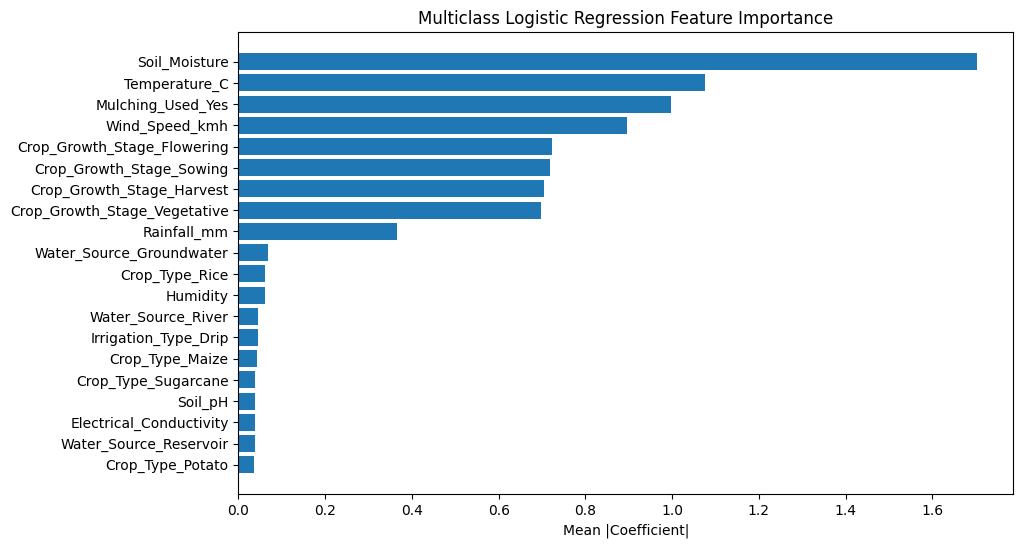

In [71]:
top = fi.head(20)

plt.figure(figsize=(10,6))
plt.barh(top['feature'][::-1], top['importance'][::-1])
plt.title("Multiclass Logistic Regression Feature Importance")
plt.xlabel("Mean |Coefficient|")
plt.show()

### PCA

In [72]:
# =========================
# Cross Validation with PCA
# =========================
def cross_validate_pca_model(x_train, y_train, n_components=30, C=1.0):

    print(f"\nCross-validating PCA + Logistic Regression (n_components={n_components})")

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_components, random_state=42)),
        ('lr', LogisticRegression(
            penalty='l2',
            C=C,
            solver='lbfgs',
            max_iter=1000,
            random_state=42
        ))
    ])

    cv_scores = cross_val_score(
        model,
        x_train,
        y_train,
        cv=5,
        scoring='roc_auc_ovr',
        n_jobs=1
    )

    return cv_scores.mean(), cv_scores.std(), cv_scores


# =========================
# Train Final PCA Model
# =========================
def train_pca_model(x_train, y_train, n_components=30, C=1.0):

    print(f"\nTraining PCA + Logistic Regression (n_components={n_components})")

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_components, random_state=42)),
        ('lr', LogisticRegression(
            penalty='l2',
            C=C,
            solver='lbfgs',
            max_iter=1000,
            random_state=42
        ))
    ])

    model.fit(x_train, y_train)

    print("Model trained successfully")
    return model


# =========================
# Evaluation
# =========================
def evaluate_model_auc(model, x, y):

    probs = model.predict_proba(x)

    if len(np.unique(y)) > 2:
        return roc_auc_score(y, probs, multi_class='ovr')
    else:
        return roc_auc_score(y, probs[:, 1])


# =========================
# EXPERIMENT
# =========================
print("\n" + "="*60)
print("EXPERIMENT: PCA + Logistic Regression")
print("="*60)


# ---- Cross Validation ----
pca_cv_mean, pca_cv_std, _ = cross_validate_pca_model(
    x_train_scaled,
    y_train,
    n_components=30,
    C=1.0
)

print(f"\n5-Fold CV AUC-ROC: {pca_cv_mean:.4f} +/- {pca_cv_std:.4f}")


# ---- Train Final Model ----
pca_model = train_pca_model(
    x_train_scaled,
    y_train,
    n_components=30,
    C=1.0
)


# ---- Training AUC ----
pca_train_auc = evaluate_model_auc(pca_model, x_train_scaled, y_train)


# ---- Final Report ----
print("\n" + "="*60)
print("PCA + LOGISTIC REGRESSION RESULTS")
print("="*60)

print(f"Training AUC-ROC: {pca_train_auc:.4f}")
print(f"CV AUC-ROC:       {pca_cv_mean:.4f} +/- {pca_cv_std:.4f}")

print("="*60)


EXPERIMENT: PCA + Logistic Regression

Cross-validating PCA + Logistic Regression (n_components=30)

5-Fold CV AUC-ROC: 0.9437 +/- 0.0007

Training PCA + Logistic Regression (n_components=30)
Model trained successfully

PCA + LOGISTIC REGRESSION RESULTS
Training AUC-ROC: 0.9437
CV AUC-ROC:       0.9437 +/- 0.0007


### L1 Regualrization

In [73]:
# =========================
# Cross Validation L1
# =========================
def cross_validate_l1(x_train, y_train, C=0.1, n_folds=5):

    print("\nCross-validating L1 Logistic Regression")

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(
            penalty='l1',
            C=C,
            solver='saga',     
            max_iter=2000,
            random_state=42
        ))
    ])

    scores = cross_val_score(
        model,
        x_train,
        y_train,
        cv=n_folds,
        scoring='roc_auc_ovr',
        n_jobs=1
    )

    return scores.mean(), scores.std(), scores


# =========================
# Train Final L1 Model
# =========================
def train_l1_model(x_train, y_train, C=0.1):

    print("\nTraining L1 Logistic Regression")

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(
            penalty='l1',
            C=C,
            solver='saga',
            max_iter=2000,
            random_state=42
        ))
    ])

    model.fit(x_train, y_train)

    return model


# =========================
# FEATURE COUNT (important for L1)
# =========================
def count_nonzero_features(model):

    lr = model.named_steps['lr']
    coef = lr.coef_

    return np.sum(np.abs(coef) > 1e-6)

print("\n" + "="*50)
print("EXPERIMENT 3: L1 Regularization + Logistic Regression")
print("="*50)


# ---- CV ----
lr_l1_cv_mean, lr_l1_cv_std, _ = cross_validate_l1(
    x_train_scaled,
    y_train,
    C=0.1,
    n_folds=5
)

print(f"\n5-Fold CV AUC-ROC: {lr_l1_cv_mean:.4f} +/- {lr_l1_cv_std:.4f}")


# ---- Train ----
lr_l1_model = train_l1_model(x_train_scaled, y_train, C=0.1)


# ---- Feature selection insight ----
n_features = count_nonzero_features(lr_l1_model)
print(f"L1 selected features: {n_features}")


# ---- Report ----
print("\n" + "="*50)
print("L1 REGULARIZATION RESULTS")
print("="*50)

print(f"CV AUC-ROC: {lr_l1_cv_mean:.4f} +/- {lr_l1_cv_std:.4f}")
print(f"Selected Features: {n_features}")

print("="*50)


EXPERIMENT 3: L1 Regularization + Logistic Regression

Cross-validating L1 Logistic Regression

5-Fold CV AUC-ROC: 0.9643 +/- 0.0006

Training L1 Logistic Regression
L1 selected features: 74

L1 REGULARIZATION RESULTS
CV AUC-ROC: 0.9643 +/- 0.0006
Selected Features: 74


### ANN

In [74]:
EPOCHS = 100
BATCH_SIZE = 64
LEARNING_RATE = 0.01

In [67]:
y_train = pd.Series(y_train).map({'Low': 0, 'Medium': 1, 'High': 2}).values

In [76]:
class DeepNN(nn.Module):
    def __init__(self, input_dim):
        super(DeepNN, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 3)
        )

    def forward(self, x):
        return self.net(x)

In [77]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = torch.FloatTensor(class_weights)

print("Class Weights:", class_weights)

Class Weights: tensor([0.5677, 0.8784, 9.9957])


In [78]:
class_weights = class_weights ** 0.5
class_weights = class_weights / class_weights.mean()

In [79]:
class_weights

tensor([0.4658, 0.5795, 1.9547])

In [80]:
def to_numpy(x):
    return x.values if hasattr(x, "values") else np.array(x)

In [81]:
def train_dnn_epoch(model, loader, optimizer, criterion):
    model.train()

    for X_batch, y_batch in loader:
        optimizer.zero_grad()

        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        loss.backward()
        optimizer.step()

In [83]:
def train_pytorch_model(model, X_train, y_train,
                        learning_rate=0.01,
                        epochs=50,
                        batch_size=64):

    X_train = to_numpy(X_train)
    y_train = to_numpy(y_train)

    X_tensor = torch.FloatTensor(X_train)
    y_tensor = torch.LongTensor(y_train)

    dataset = TensorDataset(X_tensor, y_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

    print(f"Training for {epochs} epochs...")

    for epoch in range(epochs):
        train_dnn_epoch(model, loader, optimizer, criterion)

        if (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch+1}/{epochs} done")

    return model, optimizer

In [84]:
def evaluate_model_cv(model, X, y):
    model.eval()

    X = to_numpy(X)
    y = to_numpy(y)

    with torch.no_grad():
        X_tensor = torch.tensor(X, dtype=torch.float32)

        logits = model(X_tensor)
        probs = torch.softmax(logits, dim=1).cpu().numpy()

    return roc_auc_score(y, probs, multi_class='ovr')

In [85]:
def cross_validate_dnn(X_train, y_train, learning_rates, n_folds=5):

    print(f"\n{n_folds}-Fold Cross Validation")
    print(f"Testing LR: {learning_rates}")

    X_train = to_numpy(X_train)
    y_train = to_numpy(y_train)

    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

    results = {lr: [] for lr in learning_rates}

    for lr in learning_rates:
        print(f"\nLR = {lr}")

        for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):

            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            y_tr, y_val = y_train[train_idx], y_train[val_idx]

            model = DeepNN(input_dim=X_train.shape[1])

            model, _ = train_pytorch_model(
                model,
                X_tr,
                y_tr,
                learning_rate=lr,
                epochs=EPOCHS,
                batch_size=BATCH_SIZE
            )

            auc = evaluate_model_cv(model, X_val, y_val)

            results[lr].append(auc)

            print(f"  Fold {fold+1}: AUC = {auc:.4f}")

        print(f"LR {lr} Mean AUC = {np.mean(results[lr]):.4f}")

    return results

In [86]:
print("\n" + "="*50)
print("EXPERIMENT: Deep Neural Network")
print("="*50)

learning_rates_to_test = [0.01]

cv_results = cross_validate_dnn(
    x_train_scaled,
    y_train,
    learning_rates_to_test,
    n_folds=5
)


EXPERIMENT: Deep Neural Network

5-Fold Cross Validation
Testing LR: [0.01]

LR = 0.01
Training for 100 epochs...
  Epoch 20/100 done
  Epoch 40/100 done
  Epoch 60/100 done
  Epoch 80/100 done
  Epoch 100/100 done
  Fold 1: AUC = 0.9866
Training for 100 epochs...
  Epoch 20/100 done
  Epoch 40/100 done
  Epoch 60/100 done
  Epoch 80/100 done
  Epoch 100/100 done
  Fold 2: AUC = 0.9858
Training for 100 epochs...
  Epoch 20/100 done
  Epoch 40/100 done
  Epoch 60/100 done
  Epoch 80/100 done
  Epoch 100/100 done
  Fold 3: AUC = 0.9860
Training for 100 epochs...
  Epoch 20/100 done
  Epoch 40/100 done
  Epoch 60/100 done
  Epoch 80/100 done
  Epoch 100/100 done
  Fold 4: AUC = 0.9871
Training for 100 epochs...
  Epoch 20/100 done
  Epoch 40/100 done
  Epoch 60/100 done
  Epoch 80/100 done
  Epoch 100/100 done
  Fold 5: AUC = 0.9857
LR 0.01 Mean AUC = 0.9862


In [87]:
best_lr = max(cv_results, key=lambda lr: np.mean(cv_results[lr]))

cv_mean = np.mean(cv_results[best_lr])
cv_std = np.std(cv_results[best_lr])

print("Best LR:", best_lr)
print("Mean CV AUC:", cv_mean)
print("Std CV AUC:", cv_std)

Best LR: 0.01
Mean CV AUC: 0.986221069404649
Std CV AUC: 0.0005283581957193984


In [88]:
deep_nn = DeepNN(input_dim=x_train_scaled.shape[1])

deep_nn, optimizer = train_pytorch_model(
    deep_nn,
    x_train_scaled,
    y_train,
    learning_rate=best_lr,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Training for 100 epochs...
  Epoch 20/100 done
  Epoch 40/100 done
  Epoch 60/100 done
  Epoch 80/100 done


: 

In [89]:
final_auc = evaluate_model_cv(deep_nn, x_train_scaled, y_train)

print("\n" + "="*50)
print("FINAL RESULTS")
print("="*50)
print(f"CV AUC: {cv_mean:.4f} ± {cv_std:.4f}")
print(f"Final Train AUC: {final_auc:.4f}")
print("="*50)


FINAL RESULTS
CV AUC: 0.9862 ± 0.0005
Final Train AUC: 0.9858


### Save Model

In [72]:
joblib.dump(deep_nn, 'deep_nn_model.joblib')

['deep_nn_model.joblib']

In [74]:
model= joblib.load('deep_nn_model.joblib')
model

MyNeuralNet(
  (net): Sequential(
    (0): Linear(in_features=42, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=3, bias=True)
  )
)

In [92]:
save_dir = "deep_nn_model"
os.makedirs(save_dir, exist_ok=True)

torch.save(deep_nn.state_dict(), os.path.join(save_dir, "model_weights.pth"))
torch.save(optimizer.state_dict(), os.path.join(save_dir, "optimizer.pth"))

joblib.dump(scaler, os.path.join(save_dir, "scaler.pkl"))

config = {
    "input_dim": x_train_scaled.shape[1],
    "best_lr": best_lr
}

with open(os.path.join(save_dir, "config.json"), "w") as f:
    json.dump(config, f)

In [125]:
with open("deep_nn_model/config.json", "r") as f:
    config = json.load(f)

model = DeepNN(input_dim=config["input_dim"])

model.load_state_dict(
    torch.load("deep_nn_model/model_weights.pth")
)

model.eval()

DeepNN(
  (net): Sequential(
    (0): Linear(in_features=42, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=3, bias=True)
  )
)

In [126]:
from google.colab import files
files.download("deep_nn_model/model_weights.pth")
files.download("deep_nn_model/config.json")
files.download("deep_nn_model/scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(os.getcwd()) 
print(os.listdir()) 
print(os.listdir("deep_nn_model"))

/content
['.config', 'deep_nn_model', 'drive', 'sample_data']
['config.json', 'model_weights.pth', 'scaler.pkl', 'optimizer.pth']


In [ ]:

dest = "/content/drive/MyDrive/deep_nn_model"
os.makedirs(dest, exist_ok=True)

shutil.copy("/content/deep_nn_model/model_weights.pth", dest)
shutil.copy("/content/deep_nn_model/config.json", dest)
shutil.copy("/content/deep_nn_model/scaler.pkl", dest)
shutil.copy("/content/deep_nn_model/optimizer.pth", dest)

'/content/drive/MyDrive/deep_nn_model/optimizer.pth'

In [ ]:
shutil.make_archive("/content/deep_nn_model", 'zip', "/content/deep_nn_model")

'/content/deep_nn_model.zip'

In [134]:
shutil.copy("/content/deep_nn_model.zip", "/content/drive/MyDrive/")

'/content/drive/MyDrive/deep_nn_model.zip'

### Load Model

In [38]:
model_path = "/content/drive/MyDrive/deep_nn_model/model_weights.pth"

In [39]:
class MyNeuralNet(nn.Module):
    def __init__(self, input_dim):
        super(MyNeuralNet, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 3)
        )

    def forward(self, x):
        return self.net(x)

input_dim = x_train.shape[1]
deep_nn = MyNeuralNet(input_dim)

state = torch.load(model_path, map_location="cpu")

deep_nn.load_state_dict(state)
deep_nn.eval()

MyNeuralNet(
  (net): Sequential(
    (0): Linear(in_features=42, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=3, bias=True)
  )
)

## Evaluate

### Confusion Matrix

In [98]:
def plot_confusion_matrix_nn(model, X, y_true):

    model.eval()

    with torch.no_grad():
        if hasattr(X, "values"):
            X = X.values

        X_tensor = torch.tensor(X, dtype=torch.float32)

        outputs = model(X_tensor)

        y_pred = torch.argmax(outputs, axis=1).numpy()

    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')

    plt.title("Confusion Matrix - Neural Network")
    plt.show()

    return cm

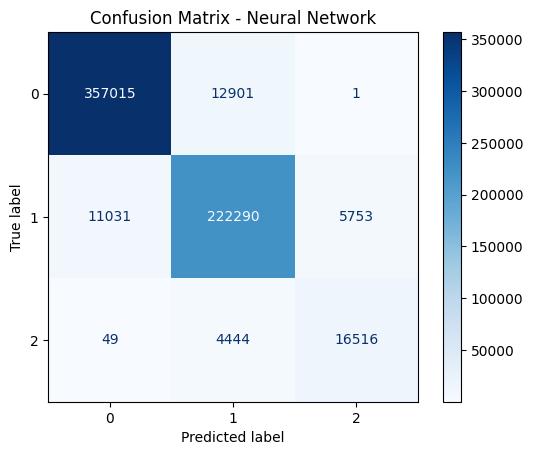

[[357015  12901      1]
 [ 11031 222290   5753]
 [    49   4444  16516]]


In [99]:
cm = plot_confusion_matrix_nn(
    deep_nn,
    x_train_scaled,
    y_train
)

print(cm)

### Classification Report

In [69]:
def nn_classification_report(model, X, y_true):

    model.eval()

    with torch.no_grad():

        if hasattr(X, "values"):
            X = X.values

        X_tensor = torch.tensor(X, dtype=torch.float32)

        outputs = model(X_tensor)

        y_pred = torch.argmax(outputs, axis=1).numpy()

    report = classification_report(y_true, y_pred)

    print("Classification Report - Neural Network\n")
    print(report)

    return report

In [70]:
nn_classification_report(
    deep_nn,
    x_train_scaled,
    y_train
)

Classification Report - Neural Network

              precision    recall  f1-score   support

           0       0.97      0.97      0.97    369917
           1       0.93      0.93      0.93    239074
           2       0.74      0.79      0.76     21009

    accuracy                           0.95    630000
   macro avg       0.88      0.89      0.89    630000
weighted avg       0.95      0.95      0.95    630000



'              precision    recall  f1-score   support\n\n           0       0.97      0.97      0.97    369917\n           1       0.93      0.93      0.93    239074\n           2       0.74      0.79      0.76     21009\n\n    accuracy                           0.95    630000\n   macro avg       0.88      0.89      0.89    630000\nweighted avg       0.95      0.95      0.95    630000\n'